# Liver Cancer Multi-Class Classification using EfficientNetV2-S

This notebook trains a deep learning model to classify liver MRI images into five categories:

- Healthy
- Angiosarcoma
- Cholangiocarcinoma
- Hemangioma
- Hepatocellular Carcinoma

Model:
- EfficientNetV2-S (Transfer Learning)

Framework:
- PyTorch

Dataset:
- Liver Cancer Multiclass Dataset (Kaggle)

Author:
- Sakib

In [ ]:
!pip install -q timm torchmetrics albumentations grad-cam seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tqdm.notebook import tqdm

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/deep learning/Liver_Dataset.zip"
extract_path = "/content/Liver_Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
from pathlib import Path

root = Path("/content/Liver_Dataset/Liver_Dataset")

folders = [x for x in root.iterdir() if x.is_dir()]

if len(folders) == 1:
    dataset_path = folders[0]
else:
    dataset_path = root

print(dataset_path)

/content/Liver_Dataset/Liver_Dataset


In [ ]:
classes = sorted([
    d.name
    for d in dataset_path.iterdir()
    if d.is_dir()
])

print(classes)

['Angiosarcoma', 'Cholangiocarcinoma', 'Healthy', 'Hemangioma', 'Hepatocellular_Carcinoma']


In [ ]:
for c in classes:

    total = len(list((dataset_path/c).glob("*")))

    print(c, total)

Angiosarcoma 2376
Cholangiocarcinoma 2512
Healthy 2400
Hemangioma 2376
Hepatocellular_Carcinoma 2328


In [ ]:

random.seed(42)

output = Path("/content/split_dataset")

train_dir = output / "train"
val_dir = output / "val"
test_dir = output / "test"

for cls in classes:

    images = list((dataset_path / cls).glob("*"))

    random.shuffle(images)

    n = len(images)

    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train = images[:train_end]
    val = images[train_end:val_end]
    test = images[val_end:]

    for folder in [train_dir, val_dir, test_dir]:
        (folder / cls).mkdir(parents=True, exist_ok=True)

    for img in train:
        shutil.copy(img, train_dir / cls / img.name)

    for img in val:
        shutil.copy(img, val_dir / cls / img.name)

    for img in test:
        shutil.copy(img, test_dir / cls / img.name)

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
for split in ["train","val","test"]:

    print(f"\n{split.upper()}")

    for cls in classes:

        count = len(os.listdir(output / split / cls))

        print(f"{cls}: {count}")


TRAIN
Angiosarcoma: 1900
Cholangiocarcinoma: 2009
Healthy: 1920
Hemangioma: 1900
Hepatocellular_Carcinoma: 1862

VAL
Angiosarcoma: 238
Cholangiocarcinoma: 251
Healthy: 240
Hemangioma: 238
Hepatocellular_Carcinoma: 233

TEST
Angiosarcoma: 238
Cholangiocarcinoma: 252
Healthy: 240
Hemangioma: 238
Hepatocellular_Carcinoma: 233


In [ ]:
from torchvision import transforms

# Training transforms (includes augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Validation/Test transforms
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print("Classes:")
print(train_dataset.classes)

Classes:
['Angiosarcoma', 'Cholangiocarcinoma', 'Healthy', 'Hemangioma', 'Hepatocellular_Carcinoma']


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Test Images :", len(test_dataset))

Train Images : 9591
Validation Images : 1200
Test Images : 1201


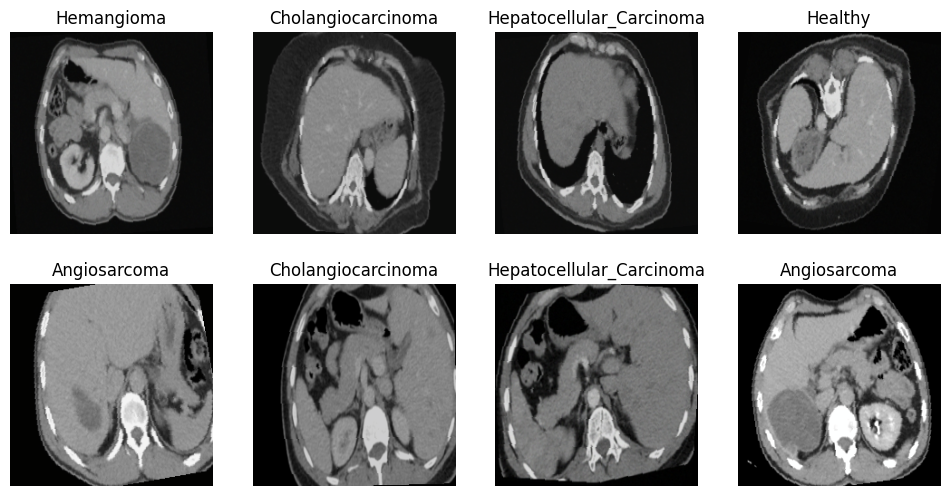

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0).numpy()

    # Undo normalization
    mean=np.array([0.485,0.456,0.406])
    std=np.array([0.229,0.224,0.225])

    img=std*img+mean
    img=np.clip(img,0,1)

    ax.imshow(img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [ ]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "tf_efficientnetv2_s",
    pretrained=True,
    num_classes=5
)

model = model.to(device)

print(model)

EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path):

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [ ]:
from torch.cuda.amp import GradScaler

scaler = GradScaler()

/tmp/ipykernel_1017/2885796805.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
NUM_EPOCHS = 20

best_accuracy = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [ ]:
print("Device :", device)
print("Classes :", train_dataset.classes)
print("Number of Classes :", len(train_dataset.classes))
print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Device : cuda
Classes : ['Angiosarcoma', 'Cholangiocarcinoma', 'Healthy', 'Hemangioma', 'Hepatocellular_Carcinoma']
Number of Classes : 5
Train Batches : 300
Validation Batches : 38
Test Batches : 38


In [ ]:
from torch.amp import autocast

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress = tqdm(loader)

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        progress.set_description(
            f"Loss:{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [ ]:
from torch.amp import autocast

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            labels = labels.to(device)

            with autocast(device_type="cuda"):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(loader)

    val_acc = 100 * correct / total

    return val_loss, val_acc

In [ ]:
best_accuracy = 0

for epoch in range(NUM_EPOCHS):

    print("="*60)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)

    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)

    history["val_acc"].append(val_acc)

    print()

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Accuracy : {train_acc:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Validation Accuracy : {val_acc:.2f}%")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save({

            "model_state_dict": model.state_dict(),

            "classes": train_dataset.classes,

            "accuracy": best_accuracy

        }, "/content/best_model.pth")

        print("✅ Best model saved!")

print()

print("Training Finished")

Epoch 1/20


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]


Train Loss : 0.4771
Train Accuracy : 93.31%
Validation Loss : 0.0012
Validation Accuracy : 99.92%
✅ Best model saved!
Epoch 2/20


  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/38 [00:00<?, ?it/s]


Train Loss : 0.0005
Train Accuracy : 99.99%
Validation Loss : 0.0000
Validation Accuracy : 100.00%
Epoch 20/20


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]


Train Loss : 0.0001
Train Accuracy : 100.00%
Validation Loss : 0.0000
Validation Accuracy : 100.00%

Training Finished


In [ ]:
checkpoint = torch.load(
    "/content/best_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best Validation Accuracy")

print(checkpoint["accuracy"])

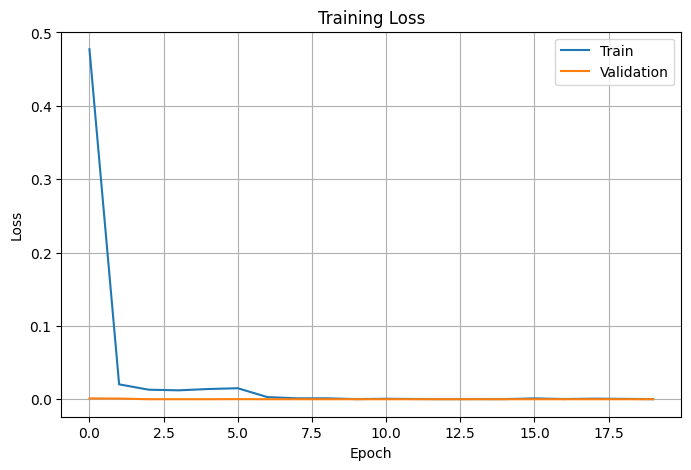

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

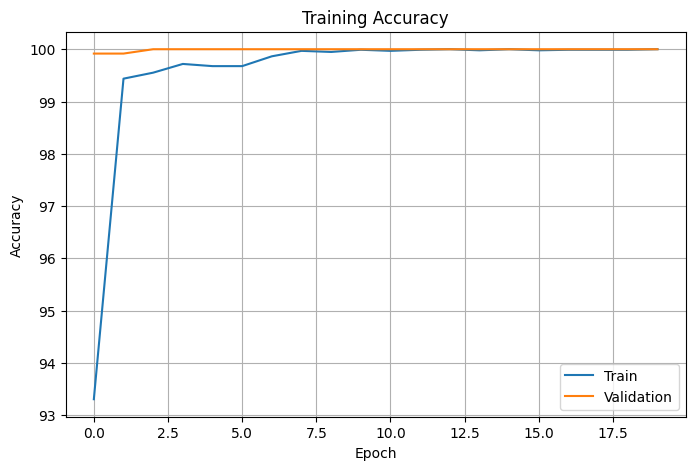

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"],label="Train")

plt.plot(history["val_acc"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    "/content/training_history.csv",
    index=False
)

print("Training history saved")

Training history saved


In [ ]:
from google.colab import files

files.download("/content/best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# using the model
!pip -q install timm

import os
import torch
import timm
from torchvision import transforms
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Check model
# ----------------------------
MODEL_PATH = "/content/best_model.pth"

if not os.path.exists(MODEL_PATH):
    print("best_model.pth not found.")
    print("Upload best_model.pth")
    files.upload()

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("best_model.pth was not uploaded.")

# ----------------------------
# Check image
# ----------------------------
image_file = None

for file in os.listdir("/content"):
    if file.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp")):
        image_file = "/content/" + file
        break

if image_file is None:
    print("No image found in /content.")
    print("Upload an image.")
    files.upload()

    for file in os.listdir("/content"):
        if file.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp")):
            image_file = "/content/" + file
            break

if image_file is None:
    raise FileNotFoundError("No image found.")

# ----------------------------
# Load checkpoint
# ----------------------------
checkpoint = torch.load(MODEL_PATH, map_location=device)

# ----------------------------
# Create model
# ----------------------------
model = timm.create_model(
    "tf_efficientnetv2_s",
    pretrained=False,
    num_classes=5
)

# Supports both checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

# ----------------------------
# Class Names
# ----------------------------
if isinstance(checkpoint, dict) and "classes" in checkpoint:
    classes = checkpoint["classes"]
else:
    classes = [
        "Angiosarcoma",
        "Cholangiocarcinoma",
        "Healthy",
        "Hemangioma",
        "Hepatocellular_Carcinoma"
    ]

# ----------------------------
# Image Transform
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

image = Image.open(image_file).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# ----------------------------
# Prediction
# ----------------------------
with torch.no_grad():

    output = model(input_tensor)

    probs = torch.softmax(output, dim=1)[0]

    confidence, pred = torch.max(probs, 0)

# ----------------------------
# Display
# ----------------------------
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

print("="*60)
print("Prediction :", classes[pred.item()])
print(f"Confidence : {confidence.item()*100:.2f}%")
print("="*60)

print("\nTop 5 Predictions\n")

top_prob, top_idx = torch.topk(probs, 5)

for i in range(5):
    print(f"{i+1}. {classes[top_idx[i]]:30s} {top_prob[i].item()*100:.2f}%")

No image found in /content.
Upload an image.
